# In-situ Electrochemical SAXS analysis

In [1]:
# %matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import glob
import os
import numpy as np
import pandas as pd
# import scienceplots
from galvani import BioLogic as BL
import eclabfiles as ecf
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display
from pybaselines import Baseline, utils

# Define Functions

# Function for reading files 

In [2]:
def read_data(file_name):
    legend_temp = []
    data_line_temp = []
    time_stamp_temp = []
    data_storing = False
    
    with open(file_name, 'r') as file:
        for line in file:
            if 'q(A-1)' in line:
                data_storing = True
                continue
            if 'Comment' in line:
                legend_temp = line.split()[4]
            if 'Date' in line:
                time_stamp_temp = line.split()[2] 
            if data_storing:
                data_line_temp.append(line.strip())
    df_temp= pd.DataFrame([line.split() for line in data_line_temp])
    df_temp= df_temp.astype(float)

    return legend_temp, time_stamp_temp ,df_temp

    

# Find files corresponding to Electrochemical events

In [11]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    
    base_time = datetime.strptime(time_dict[1], '%Y-%m-%dT%H:%M:%S')

    for key in time_dict:
        current_time = datetime.strptime(time_dict[key], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = key
    
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    
    
    return nearest_key, new_time_dict


# Upload/read data files for SAXS

In [4]:
os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240808_2503-SKJB_1MLITFSI-DOLDME_50uL_1G1PS\cycle')
mpr = BL.MPRfile(r'./20240808_2503-SKJB_1mg_1MLiTFSI_DOLDME_0pt1LiNO3_50uL_1G1PS_C02.mpr')

file_list = glob.glob('*_0_*.dat')

legend = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp = {} #Dictionary to store the time of file creation
key = 0
file_dictionary = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list:
    key += 1
    legend[key], time_stamp[key], file_dictionary[key] = read_data(data_file)

    
print('Number of files:',key)

Number of files: 1001


# Plot Data

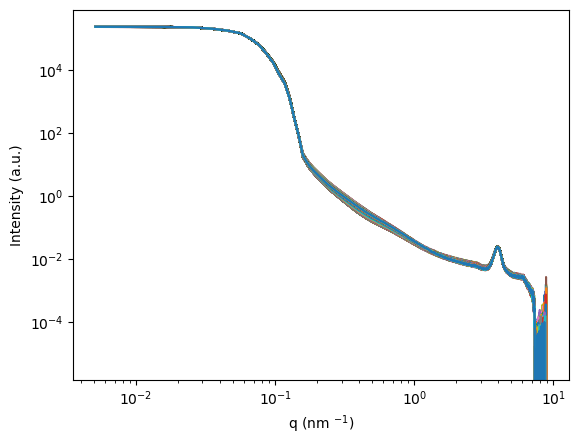

In [5]:
plt.figure()
#df_log = df[1].apply(np.log, axis=0)
plt.style.use('default')
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
#    plt.legend(legend[ikey])
    
#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

plt.xscale('log')
plt.yscale('log')
#plt.xlim(0.5,30)
#plt.ylim(0.001,0.2)

# Load electrochemical (EC Lab) file

Indices for cycle change [961, 5886, 10270, 13952, 17345, 20610, 23441, 26185, 28603, 30988, 33104]

Absolute times for change in electrochemical state: 
[960.00037574835, 25573.205436497636, 47482.697776797344, 65881.15932874358, 82833.19031890691, 99144.46986062743, 113288.4555149551, 126996.94667236973, 139073.22096033162, 150983.98802391044, 161554.83607784566]


Text(0, 0.5, 'Potential (V)')

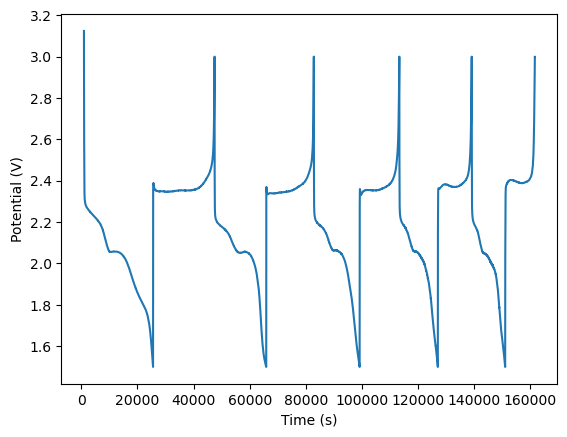

In [6]:
plt.figure()
# mpr = BL.MPRfile(r'./20240805_2503-SKJB_1pt3mg_satDME_200HFE_1G1PS_50uL_C02.mpr')
mpr = BL.MPRfile(r'./20240808_2503-SKJB_1mg_1MLiTFSI_DOLDME_0pt1LiNO3_50uL_1G1PS_C02.mpr')
elec_df_temp = pd.DataFrame(mpr.data)
# print(elec_df_temp)

    # Filter the data for the OCV from the dataframe 
filter = elec_df_temp['Ns'] != 0
elec_df = elec_df_temp[filter]
elec_df.to_csv('electrochem_datafile.txt', sep = '\t')

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0], 'time/s'])

for line in range(len(elec_df['Ns'])-1):
    if elec_df['Ns'].iloc[line] != elec_df['Ns'].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 'time/s'])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df['time/s']
Elec_Ydata = elec_df['Ewe/V']
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data segregation 

Total number of cycles: 5

Biologic data file line details:
Line numbers for each electrochemical change event : [961, 5886, 10270, 13952, 17345]
Corresponding times for each electrochemical change event:  ['960.00', '25573.21', '47482.70', '65881.16', '82833.19']


(0.001, 40)

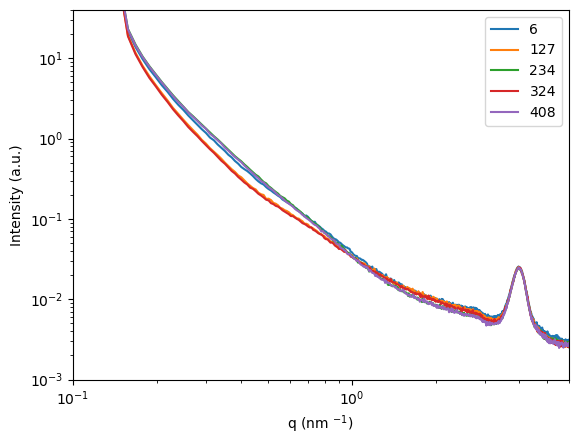

In [14]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))


change_cycle_line = []
discharge_start_time = []
saxs_file_numbers = []

starting_index_for_EC_data = 2*starting_cycle-2
ending_index_for_EC_data = 2*end_cycle

print('\nBiologic data file line details:')
print('Line numbers for each electrochemical change event :',
       [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
print('Corresponding times for each electrochemical change event: ', 
      [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

# creates a new data frame for the plot
elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                         cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

plt.style.use('default')
plt.figure()

# find the corresponding starting abd ending SAXS file
for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
    saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp)
    saxs_file_numbers.append(saxs_file_index)
    X1_data = 10*file_dictionary[saxs_file_index].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y1_data = file_dictionary[saxs_file_index].iloc[:,1]
    plt.plot(X1_data, Y1_data, label= saxs_file_index)
""" # Printing the file details for manual verification of file numbers   
    print(f"Starting SAXS file no.: {saxs_file_index}")
    print('Time stamps:')
    print(time_stamp[saxs_file_index])"""

starting_file = saxs_file_numbers[0]
last_file = saxs_file_numbers[-1]

plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,6)
plt.ylim(0.001,40)

# Not required

In [ ]:
print(f'profile for cycle number: {starting_cycle},{end_cycle}')
plt.style.use('default')

plot1 = plt.subplot2grid((4, 4), (0, 0), colspan=4) 
plot2 = plt.subplot2grid((4, 4), (1, 0), rowspan=3, colspan=2) 
plot3 = plt.subplot2grid((4, 4), (1, 2), rowspan=3, colspan=2)

relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
plot1.plot(relative_time, elec_df_2['Ewe/V'], color = 'r')
# plot1.set_xlabel('Time(s)')
plot1.set_ylabel('Potential (V)')
plot1.set_xticks([])


norm = Normalize(vmin = starting_file, vmax = discharge_file+1)

for file_number in range(starting_file , discharge_file+1): 
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.Blues(norm(file_number))
    plot2.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
# plot2.legend()

plot2.set_xlabel('q (nm $^{-1}$)')
plot2.set_ylabel('Intensity (a.u.)')


"""plot2.set_xlim(1,30)
plot2.set_ylim(0.0004,0.01)"""
# plot2.set_title('charging')
plot2.set_yticks([])
plot2.set_yticklabels([])
plot2.set_xscale('log')
plot2.set_yscale('log')
# plot2.set_yscale('log')

norm = Normalize(vmin = discharge_file+1, vmax = last_file)

for file_number in range(discharge_file+1 , last_file+1):  
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.Blues(norm(file_number))
    plot3.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
    
# plot3.legend()
plot3.set_xlabel('q (nm $^{-1}$)')
"""plot3.set_xlim(1,30)
plot3.set_ylim(0.0004,0.01)"""
plot3.set_yticks([])
plot3.set_yticklabels([])
# plot3.set_title('discharge')
plot3.set_xscale('log')
plot3.set_yscale('log')
# plot3.set_yscale('log')
plt.tight_layout()

# SAXS Colourplot without background correction 

profile for cycle number: 1 to 2


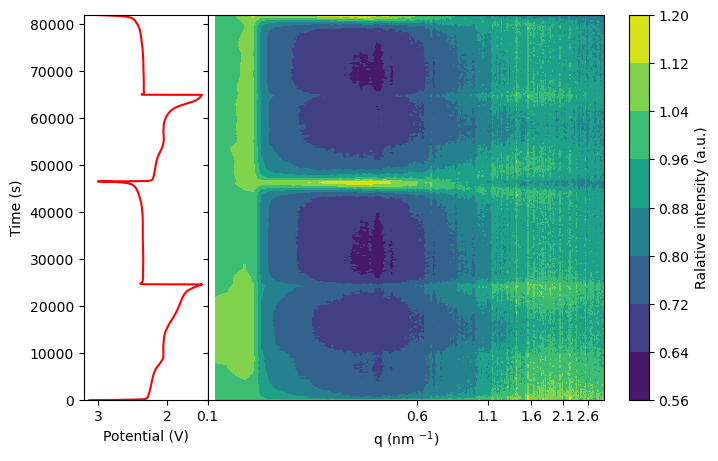

In [15]:
import matplotlib.ticker as mticker
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
plt.style.use('default')
keys = list(new_time_dict.keys())
time_t1 = []
Intensity_list = []

X1_data_temp = 10*file_dictionary[starting_file].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
lower_bound = 0.1
upper_bound = 3
indices_within_range = np.where((X1_data_temp >= lower_bound) & (X1_data_temp <= upper_bound))
#print("Positions where data is within the range:", indices_within_range)

X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
#print("Values at positions within the range:", X1_data_filtered_positions)
start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# print('valuesof rows', start_row, end_row)

for file_number in range(starting_file, last_file+1):  
    Y1_data = [(file_dictionary[file_number].iloc[start_row:end_row+1,1])/file_dictionary[starting_file].iloc[start_row:end_row+1,1]]
    time_t1.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
    Intensity_list.append(list(Y1_data))   

# print(norm_intensity)
normIntensity_array = np.array(Intensity_list)
# print(normIntensity_array)
X, Y = np.meshgrid(X1_data_filtered_positions, time_t1)
normIntensity_flat = normIntensity_array[:, 0, :]
np.savetxt('file.txt',normIntensity_flat)

cmap1 = plt.colormaps.get_cmap('viridis')  # Replace 'RdPu' with your desired colormap

# data for the charge-discharge plot
relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
# Finding minimum and maximum times to limit the axs from having automatic margins in subplot
min_time = relative_time.min()
max_time = relative_time.max()

fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
axs[0].plot(elec_df_2['Ewe/V'], relative_time,  color = 'r')

# plot1.set_xlabel('Time(s)')
axs[0].invert_xaxis()
axs[0].set_ylabel('Time (s)')
axs[0].set_xlabel('Potential (V)')
axs[0].set_ylim(min_time, max_time)

contour = axs[1].contourf(X, Y,normIntensity_flat, cmap = cmap1)
cbar = fig.colorbar(contour, ax = axs[1], label = 'Ralative intensity (a.u.)')

# Adjust the space between the two subplots
fig.subplots_adjust(wspace = 0)

axs[1].set_xscale('log')
axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axs[1].xaxis.set_minor_formatter(mticker.ScalarFormatter())
axs[1].set_xlabel('q (nm $^{-1}$)')

# Define custom ticks and labels
ticks = np.arange(0.1, 3, 0.5)
tick_labels = [f'{tick:.1f}' for tick in ticks]

axs[1].set_xticks(ticks)
axs[1].set_xticklabels(tick_labels)
axs[1].xaxis.set_minor_locator(mticker.NullLocator())  # Remove minor ticks



# Background correction with empty cell subtraction 

File used for background: 20240730_Empty_Cell_saxs.dat


(0.01, 6)

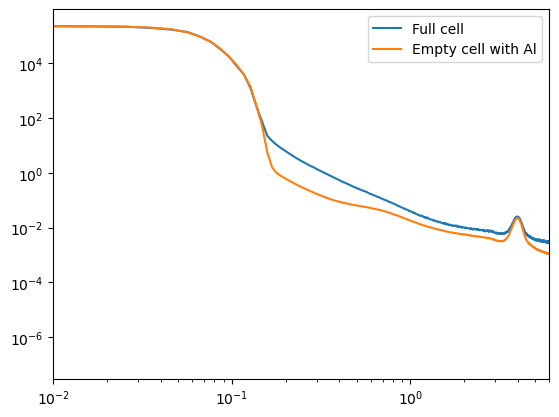

In [16]:
# os.chdir(r'C:\Users\b1104371\OneDrive - Universität Salzburg\Research\Electrolyte variation\Charecterizations\SAXS\After_Beamtime\2503SKJB\20240604_2503-SKJB_6MECDEC_100volHFE')
saxs_background_file = glob.glob('20240730_Empty_Cell_saxs.dat')
#print(file_list)

for input in saxs_background_file:
    a1,a2,SAXS_background = read_data(input)

plt.figure()  
print('File used for background:',input)

plt.plot(10*file_dictionary[1].iloc[:,0],file_dictionary[1].iloc[:,1], label = 'Full cell')
plt.plot(10*SAXS_background.iloc[:,0], SAXS_background.iloc[:,1], label = 'Empty cell with Al')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(0.01,6)
#plt.ylim(0.001,40)
#print(SAXS_background)
# print(file_dictionary[1].head())
# print(file_dictionary[250].head())

# Create a new dictionary with corrected SAXS

(0.0001, 40)

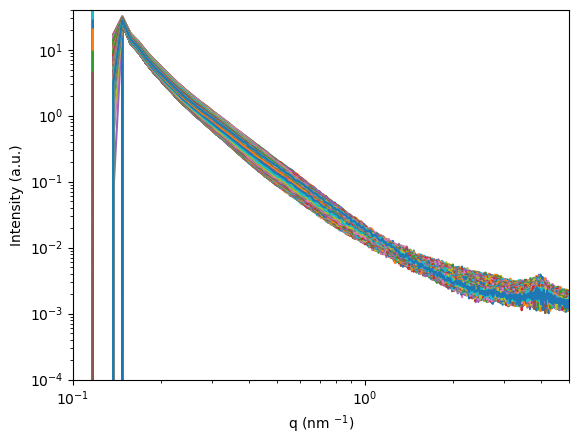

In [17]:
plt.figure()
emptyCell_corrected_saxs_files = {}
for ikey in file_dictionary:
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    modified_Y = Y_data - SAXS_background.iloc[:len(Y_data),1]
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_saxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,5)
plt.ylim(0.0001,40)
#print(corrected_waxs_files[1].head(30))

profile for cycle number: 1 to 2


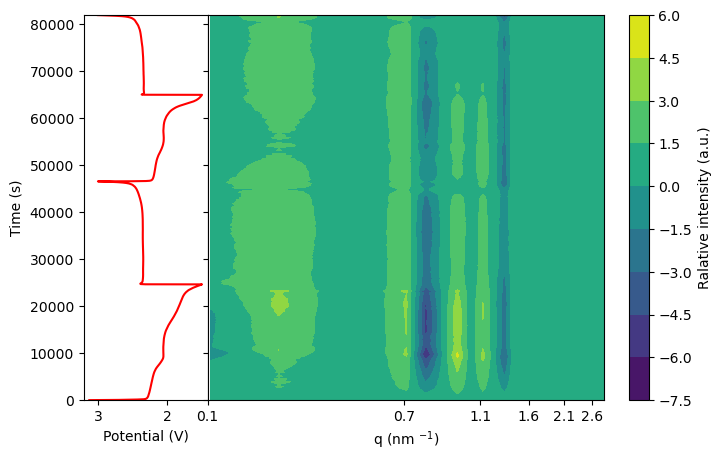

In [18]:
import matplotlib.ticker as mticker
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
plt.style.use('default')
keys = list(new_time_dict.keys())
time_t1 = []
Intensity_list = []

X1_data_temp = 10*emptyCell_corrected_saxs_files[starting_file].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
lower_bound = 0.15
upper_bound = 3
indices_within_range = np.where((X1_data_temp >= lower_bound) & (X1_data_temp <= upper_bound))
#print("Positions where data is within the range:", indices_within_range)

X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
#print("Values at positions within the range:", X1_data_filtered_positions)
start_row = np.min(indices_within_range)
end_row = np.max(indices_within_range)

# print('valuesof rows', start_row, end_row)

for file_number in range(starting_file, last_file+1):  
    Y1_data = [(emptyCell_corrected_saxs_files[file_number].iloc[start_row:end_row+1,1])/emptyCell_corrected_saxs_files[starting_file].iloc[start_row:end_row+1,1]]
    time_t1.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
    Intensity_list.append(list(Y1_data))   

#print(norm_intensity)
normIntensity_array = np.array(Intensity_list)
#print(normIntensity_array)
X, Y = np.meshgrid(X1_data_filtered_positions, time_t1)
normIntensity_flat = normIntensity_array[:, 0, :]
np.savetxt('file.txt',normIntensity_flat)

cmap1 = plt.colormaps.get_cmap('viridis')  # Replace 'RdPu' with your desired colormap

# data for the charge-discharge plot
relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
# Finding minimum and maximum times to limit the axs from having automatic margins in subplot
min_time = relative_time.min()
max_time = relative_time.max()

fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
axs[0].plot(elec_df_2['Ewe/V'], relative_time,  color = 'r')

# plot1.set_xlabel('Time(s)')
axs[0].invert_xaxis()
axs[0].set_ylabel('Time (s)')
axs[0].set_xlabel('Potential (V)')
axs[0].set_ylim(min_time, max_time)

contour = axs[1].contourf(X, Y,normIntensity_flat, cmap = cmap1)
cbar = fig.colorbar(contour, ax = axs[1], label = 'Ralative intensity (a.u.)')

# Adjust the space between the two subplots
fig.subplots_adjust(wspace = 0)

axs[1].set_xscale('log')
axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
axs[1].xaxis.set_minor_formatter(mticker.ScalarFormatter())
axs[1].set_xlabel('q (nm $^{-1}$)')

# Define custom ticks and labels
ticks = np.arange(0.15, 3, 0.5)
tick_labels = [f'{tick:.1f}' for tick in ticks]

axs[1].set_xticks(ticks)
axs[1].set_xticklabels(tick_labels)
axs[1].xaxis.set_minor_locator(mticker.NullLocator())  # Remove minor ticks

# WAXS data polotting

In [19]:
file_list_waxs = glob.glob('*_1_*.dat')
#print(file_list)


legend_waxs = {} #Dictionary for storing the comments from experiment data files to be used as legends later
time_stamp_waxs = {} #Dictionary to store the time of file creation
key = 0
file_dictionary_waxs = {} # Dictionary for storing all the pandas data file 

# Read all the files data from the directory and also the comments and file generation time in seperate pd dataframe

for data_file in file_list_waxs:
    key += 1
    legend_waxs[key], time_stamp_waxs[key], file_dictionary_waxs[key] = read_data(data_file)
    
print('Number of files:',key)


Number of files: 1001


# Plot the WAXS data

Text(0, 0.5, 'Intensity (a.u.)')

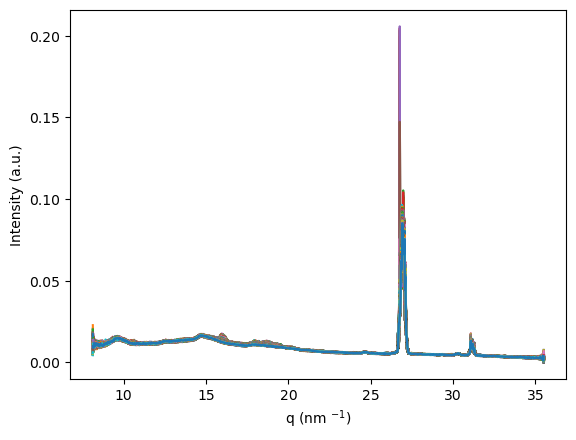

In [20]:
#df_log = df[1].apply(np.log, axis=0)
plt.style.use('default')
for ikey in file_dictionary_waxs:
    X_data = 10*file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
#    plt.legend(legend[ikey])
    
#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#check

profile for cycle number: 1 to 2


Text(0.5, 0, 'q (nm $^{-1}$)')

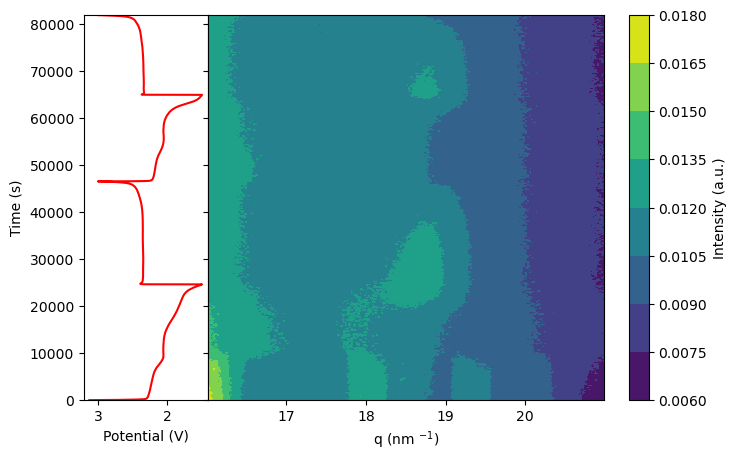

In [21]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
plt.style.use('default')
keys = list(new_time_dict.keys())
time_t1_waxs = []
Intensity_list_waxs = []


X1_data_temp_waxs = 10*file_dictionary_waxs[starting_file].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
lower_bound_waxs = 16
upper_bound_waxs = 21
indices_within_range_waxs = np.where((X1_data_temp_waxs >= lower_bound_waxs) & (X1_data_temp_waxs <= upper_bound_waxs))
#print("Positions where data is within the range:", indices_within_range)

X1_data_filtered_positions2 = X1_data_temp_waxs.iloc[indices_within_range_waxs]
#print("Values at positions within the range:", X1_data_filtered_positions2)

start_row_waxs = np.min(indices_within_range_waxs)
end_row_waxs = np.max(indices_within_range_waxs)

# print('valuesof rows', start_row, end_row)

for file_number in range(starting_file, last_file+1):  
    Y1_data_waxs = [(file_dictionary_waxs[file_number].iloc[start_row_waxs:end_row_waxs+1,1])]
    time_t1_waxs.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
    Intensity_list_waxs.append(list(Y1_data_waxs))   
#print('time values',time_t1_waxs)
# print(norm_intensity)
normIntensity_array_waxs = np.array(Intensity_list_waxs)
# print(normIntensity_array)
X, Y = np.meshgrid(X1_data_filtered_positions2, time_t1_waxs)
normIntensity_flat_waxs = normIntensity_array_waxs[:, 0, :]
#np.savetxt('file.txt',normIntensity_flat)

cmap1 = plt.colormaps.get_cmap('viridis')  # Replace 'RdPu' with your desired colormap

# data for the charge-discharge plot
relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
# Finding minimum and maximum times to limit the axs from having automatic margins in subplot
min_time = relative_time.min()
max_time = relative_time.max()

fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
axs[0].plot(elec_df_2['Ewe/V'], relative_time,  color = 'r')

# plot1.set_xlabel('Time(s)')
axs[0].invert_xaxis()
axs[0].set_ylabel('Time (s)')
axs[0].set_xlabel('Potential (V)')
axs[0].set_ylim(min_time, max_time)

contour = axs[1].contourf(X, Y,normIntensity_flat_waxs, cmap = cmap1)
cbar = fig.colorbar(contour, ax = axs[1], label = 'Intensity (a.u.)')

# Adjust the space between the two subplots
fig.subplots_adjust(wspace = 0)

axs[1].set_xlabel('q (nm $^{-1}$)')

# Background correction and plotting for the WAXS

# Background correction with a polynomial

[0.00969447 0.00967384 0.00965428 ... 0.0023707  0.00241717 0.00246493]
first file printed as corrected_waxs.txt


Text(0, 0.5, 'Intensity (a.u.)')

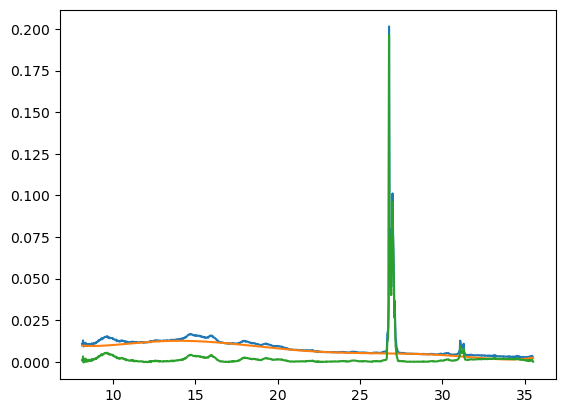

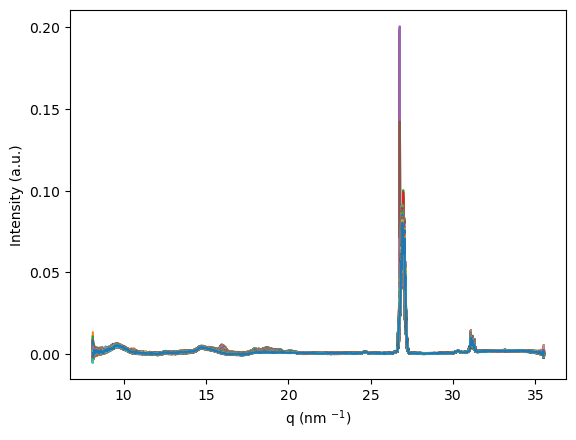

In [34]:
X_data = []
Y_data = []

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary_waxs[files].iloc[:,1]
    else:
        x = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary_waxs[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

output_filename = "corrected_waxs.txt"
with open(output_filename, 'w') as f:
    for x,y in zip(X_data, modified_Y):
        f.write(f"{x}\t{y}\n")

print(f"first file printed as {output_filename}")

# Create background corrected WAXS dataframe

plt.figure("After polynomial background correction")

corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = 10*file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#print(corrected_waxs_files[1].head(30))


# Colour plot of Background corrected WAXS

profile for cycle number: 1 to 2


Text(0.5, 0, 'q (nm $^{-1}$)')

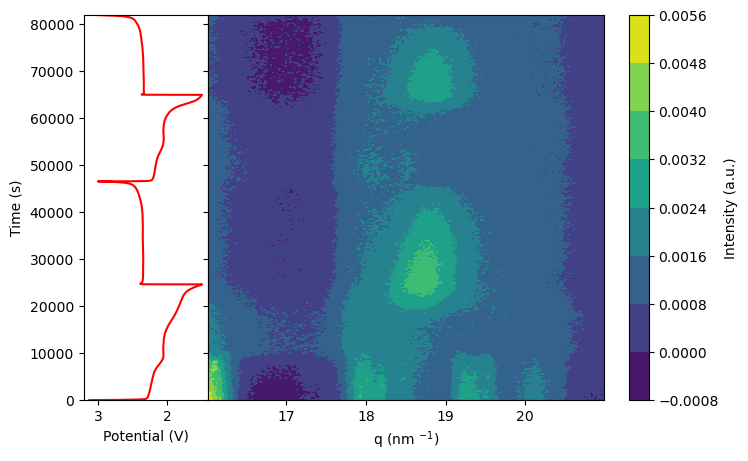

In [24]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
plt.style.use('default')
keys = list(new_time_dict.keys())
time_t1_waxs = []
Intensity_list_waxs = []


X1_data_temp_waxs = corrected_waxs_files[starting_file].iloc[:,0] 
#print(X1_data_temp_waxs)
lower_bound_waxs = 16
upper_bound_waxs = 21
indices_within_range_waxs = np.where((X1_data_temp_waxs >= lower_bound_waxs) & (X1_data_temp_waxs <= upper_bound_waxs))
#print("Positions where data is within the range:", indices_within_range_waxs)

X1_data_filtered_positions2 = X1_data_temp_waxs.iloc[indices_within_range_waxs]
#print("Values at positions within the range:", X1_data_filtered_positions2)

start_row_waxs = np.min(indices_within_range_waxs)
end_row_waxs = np.max(indices_within_range_waxs)

# print('valuesof rows', start_row, end_row)

for file_number in range(starting_file, last_file+1):  
    Y1_data_waxs = [(corrected_waxs_files[file_number].iloc[start_row_waxs:end_row_waxs+1,1])]
    time_t1_waxs.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
    Intensity_list_waxs.append(list(Y1_data_waxs))   
#print('time values',time_t1_waxs)
# print(norm_intensity)
normIntensity_array_waxs = np.array(Intensity_list_waxs)
# print(normIntensity_array)
X, Y = np.meshgrid(X1_data_filtered_positions2, time_t1_waxs)
normIntensity_flat_waxs = normIntensity_array_waxs[:, 0, :]
#np.savetxt('file.txt',normIntensity_flat)

cmap1 = plt.colormaps.get_cmap('viridis')  # Replace 'RdPu' with your desired colormap

# data for the charge-discharge plot
relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
# Finding minimum and maximum times to limit the axs from having automatic margins in subplot
min_time = relative_time.min()
max_time = relative_time.max()

fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
axs[0].plot(elec_df_2['Ewe/V'], relative_time,  color = 'r')

# plot1.set_xlabel('Time(s)')
axs[0].invert_xaxis()
axs[0].set_ylabel('Time (s)')
axs[0].set_xlabel('Potential (V)')
axs[0].set_ylim(min_time, max_time)

contour = axs[1].contourf(X, Y,normIntensity_flat_waxs, cmap = cmap1)
cbar = fig.colorbar(contour, ax = axs[1], label = 'Intensity (a.u.)')

# Adjust the space between the two subplots
fig.subplots_adjust(wspace = 0)

axs[1].set_xlabel('q (nm $^{-1}$)')

# Background correction with empty cell subtraction 

File used for WAXS background: 20240730_Empty_Cell_waxs.dat


Text(0, 0.5, 'Intensity (a.u.)')

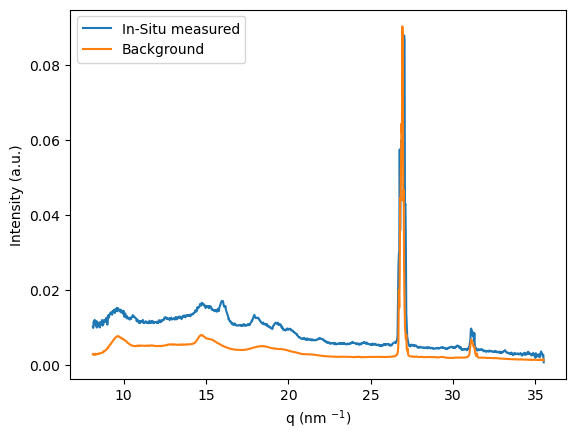

In [25]:
waxs_background_file = glob.glob('20240730_Empty_Cell_waxs.dat')

WAXS_background = {} # Dictionary for storing all the pandas data file 

for input in waxs_background_file:
    a1,a2,WAXS_background = read_data(input)
    
print('File used for WAXS background:', input)

plt.plot(10*file_dictionary_waxs[50].iloc[:,0], file_dictionary_waxs[10].iloc[:,1], label = "In-Situ measured")
plt.plot(10*WAXS_background.iloc[:,0], WAXS_background.iloc[:,1], label = 'Background')
plt.legend()
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

(-0.02, 0.05)

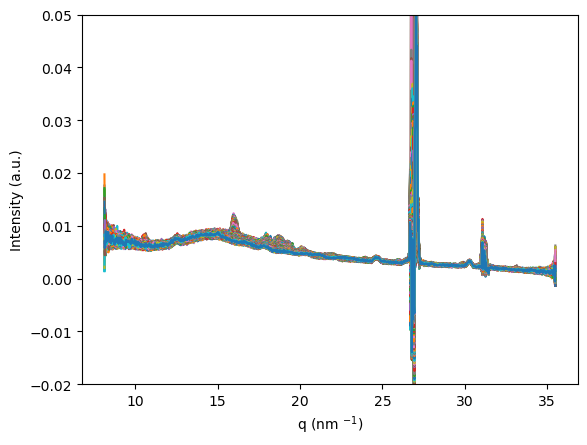

In [28]:
emptyCell_corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = 10*file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - WAXS_background.iloc[:,1]
    plt.plot(X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02,0.05)
#print(corrected_waxs_files[1].head(30))

profile for cycle number: 1 to 2


Text(0.5, 0, 'q (nm $^{-1}$)')

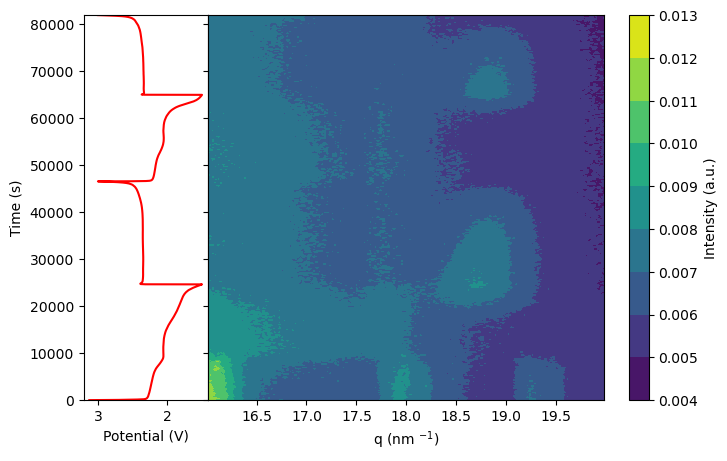

In [29]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
plt.style.use('default')
keys = list(new_time_dict.keys())
time_t1_waxs = []
Intensity_list_waxs = []


X1_data_temp_waxs = emptyCell_corrected_waxs_files[starting_file].iloc[:,0] 
#print(X1_data_temp_waxs)
lower_bound_waxs = 16
upper_bound_waxs = 20
indices_within_range_waxs = np.where((X1_data_temp_waxs >= lower_bound_waxs) & (X1_data_temp_waxs <= upper_bound_waxs))
#print("Positions where data is within the range:", indices_within_range_waxs)

X1_data_filtered_positions3 = X1_data_temp_waxs.iloc[indices_within_range_waxs]
#print("Values at positions within the range:", X1_data_filtered_positions2)

start_row_waxs = np.min(indices_within_range_waxs)
end_row_waxs = np.max(indices_within_range_waxs)

# print('valuesof rows', start_row, end_row)

for file_number in range(starting_file, last_file+1):  
    Y1_data_waxs = [(emptyCell_corrected_waxs_files[file_number].iloc[start_row_waxs:end_row_waxs+1,1])]
    time_t1_waxs.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
    Intensity_list_waxs.append(list(Y1_data_waxs))   
#print('time values',time_t1_waxs)
# print(norm_intensity)
normIntensity_array_waxs = np.array(Intensity_list_waxs)
# print(normIntensity_array)
X, Y = np.meshgrid(X1_data_filtered_positions3, time_t1_waxs)
normIntensity_flat_waxs = normIntensity_array_waxs[:, 0, :]
#np.savetxt('file.txt',normIntensity_flat)

cmap1 = plt.colormaps.get_cmap('viridis')  # Replace 'RdPu' with your desired colormap

# data for the charge-discharge plot
relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
# Finding minimum and maximum times to limit the axs from having automatic margins in subplot
min_time = relative_time.min()
max_time = relative_time.max()

fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
axs[0].plot(elec_df_2['Ewe/V'], relative_time,  color = 'r')

# plot1.set_xlabel('Time(s)')
axs[0].invert_xaxis()
axs[0].set_ylabel('Time (s)')
axs[0].set_xlabel('Potential (V)')
axs[0].set_ylim(min_time, max_time)

contour = axs[1].contourf(X, Y,normIntensity_flat_waxs, cmap = cmap1)
cbar = fig.colorbar(contour, ax = axs[1], label = 'Intensity (a.u.)')

# Adjust the space between the two subplots
fig.subplots_adjust(wspace = 0)

axs[1].set_xlabel('q (nm $^{-1}$)')